# DonorPulse — Donor Retention & Intelligence Analysis

## Business Objective

This project analyzes large-scale donation data from DonorsChoose.org to understand donor retention, donation behavior, and donor lifecycle patterns.

The analysis focuses on identifying:
- The proportion of one-time versus repeat donors
- How donation frequency relates to donor value
- High-value and at-risk donor segments using RFM analysis
- Retention patterns across donor cohorts
- Statistical differences between one-time and repeat donor value

The goal is to translate transactional donation data into actionable donor-retention strategies.


## 1. Dataset & Data Validation

The analysis uses the official DonorsChoose Open Data containing donation and project-level records.

The donation dataset contains approximately 11.38 million donation records, while the project dataset contains approximately 2.15 million project records.

Before analysis, the data was loaded into PostgreSQL and validated for:
- Record counts
- Donation amounts
- Donation and project identifiers
- Donation-to-project matching
- Donor-level aggregation consistency

All 11,377,479 donation records were successfully matched to project records, resulting in a 100% match rate.

Raw record-level data is kept locally and is not included in the public repository.


In [20]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from dotenv import load_dotenv
import psycopg2

In [ ]:


load_dotenv()

conn = psycopg2.connect(
    host="localhost",
    database="donor_retention",
    user="postgres",
    password=os.getenv("POSTGRES_PASSWORD")
)

print("Database connected successfully!")

Database connected successfully!


## 2. One-Time vs Repeat Donors

A key retention question is whether donors return after their initial contribution.

Donors are classified as:
- **One-time donors:** donors with exactly one donation
- **Repeat donors:** donors with two or more donations

This comparison helps determine whether donor retention is primarily a donor-count problem or a revenue-value problem.


In [19]:
query = """
SELECT
    donation_count,
    COUNT(*) AS donors,
    ROUND(AVG(total_donated), 2) AS avg_donated_per_donor
FROM (
    SELECT
        donor_id,
        COUNT(*) AS donation_count,
        SUM(amount) AS total_donated
    FROM donations_raw
    GROUP BY donor_id
) d
GROUP BY donation_count
ORDER BY donation_count;
"""

frequency_df = pd.read_sql_query(query, conn)

frequency_df.head(10)

C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_14740\811204122.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  frequency_df = pd.read_sql_query(query, conn)


,donation_count,donors,avg_donated_per_donor
0,1,2463949,47.70
1,2,489979,108.79
2,3,178477,175.70
3,4,90600,241.70
4,5,55093,306.30
5,6,36071,383.22
6,7,25692,452.96
7,8,19365,521.76
8,9,14681,578.71
9,10,11726,673.06


In [22]:
query = """
SELECT
    donor_id,
    COUNT(*) AS donation_count,
    SUM(amount) AS total_donated
FROM donations_raw
GROUP BY donor_id;
"""

donor_value_df = pd.read_sql_query(query, conn)

donor_value_df["donor_segment"] = donor_value_df["donation_count"].apply(
    lambda x: "One-time" if x == 1 else "Repeat"
)

donor_value_df[
    ["donation_count", "total_donated", "donor_segment"]
].head()

C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_14740\858719696.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  donor_value_df = pd.read_sql_query(query, conn)


,donation_count,total_donated,donor_segment
0,1,10.00,One-time
1,1,50.00,One-time
2,1,99.00,One-time
3,11,634.95,Repeat
4,6,235.00,Repeat


In [ ]:


one_time = donor_value_df.loc[
    donor_value_df["donor_segment"] == "One-time",
    "total_donated"
]

repeat = donor_value_df.loc[
    donor_value_df["donor_segment"] == "Repeat",
    "total_donated"
]

statistic, p_value = mannwhitneyu(
    one_time,
    repeat,
    alternative="two-sided"
)

print("Mann–Whitney U statistic:", statistic)
print("p-value:", p_value)

Mann–Whitney U statistic: 388792507966.0
p-value: 0.0


### Business Insight

The analysis shows that **71.08% of donors are one-time donors**, while repeat donors account for only **28.92%** of the donor base.

However, repeat donors generate approximately **86.8% of total donation value**.

This indicates that donor retention is not simply a matter of increasing the number of returning donors. Retaining existing repeat donors and converting promising one-time donors can have a disproportionate impact on long-term donation value.


## 3. RFM Donor Segmentation

RFM (Recency, Frequency, Monetary) analysis is used to segment donors based on their engagement and contribution behavior.

- **Recency:** How recently a donor contributed
- **Frequency:** How often a donor contributed
- **Monetary:** How much a donor contributed

Each dimension is scored using quintiles, allowing donors to be grouped into meaningful lifecycle segments such as Champions, Loyal Donors, Potential Loyalists, New / Promising, and At Risk.


In [23]:
query = """
SELECT *
FROM donor_rfm
"""

rfm_df = pd.read_sql_query(query, conn)

rfm_df[[
    "donor_segment",
    "recency_score",
    "frequency_score",
    "monetary_score",
    "rfm_score"
]].head()

C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_14740\2188623527.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rfm_df = pd.read_sql_query(query, conn)


,donor_segment,recency_score,frequency_score,monetary_score,rfm_score
0,New / Promising,5,1,1,511
1,New / Promising,5,1,1,511
2,New / Promising,5,1,1,511
3,New / Promising,5,1,1,511
4,New / Promising,5,1,1,511


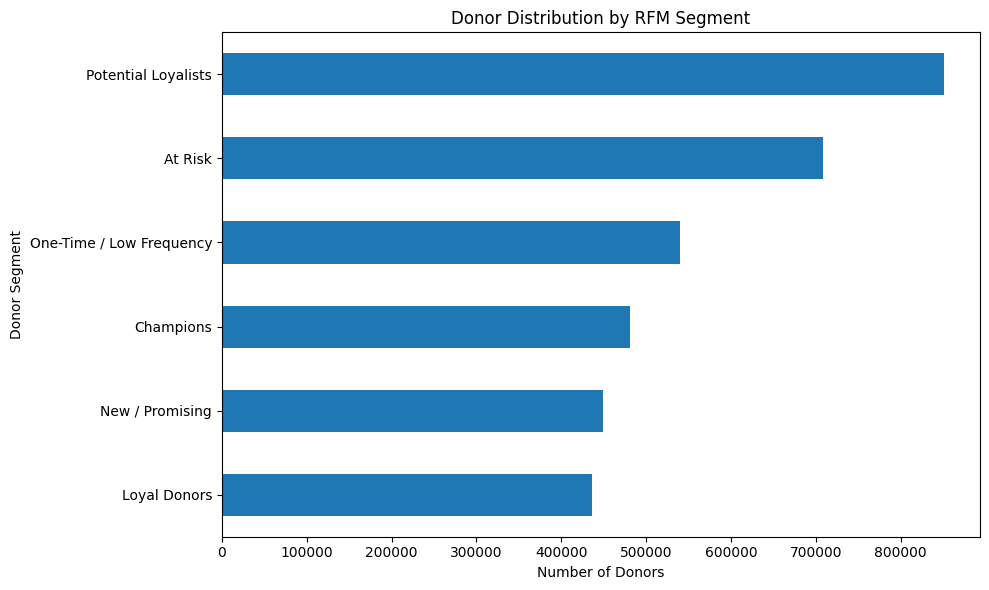

In [ ]:


segment_counts = (
    rfm_df["donor_segment"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind="barh")

plt.title("Donor Distribution by RFM Segment")
plt.xlabel("Number of Donors")
plt.ylabel("Donor Segment")
plt.tight_layout()
plt.show()

### RFM Business Insight

The RFM segmentation highlights meaningful differences in donor engagement and value.

The largest segment is **Potential Loyalists (24.55%)**, followed by **At Risk donors (20.43%)**. Champions represent **13.89%** of donors, while New / Promising donors account for **12.96%**.

The size of the At Risk segment suggests that re-engagement should be a major retention priority, while Champions and Loyal Donors should be protected through continued engagement.


## 4. Cohort Retention Analysis

Cohort analysis tracks donors based on the month of their first donation and measures how many continue donating in subsequent months.

The first donation month is treated as **Month 0**, representing the donor initial contribution. Subsequent months show how donor retention changes over time.

The cohort retention heatmap helps identify whether donors acquired during different periods exhibit different retention patterns and where the largest drop-offs occur.


In [ ]:
query = """
SELECT
    cohort_month,
    months_since_cohort,
    retention_percentage
FROM donor_cohort_retention
ORDER BY cohort_month, months_since_cohort;
"""

cohort_df = pd.read_sql_query(query, conn)

cohort_df.head()

C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_29448\4088278003.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohort_df = pd.read_sql_query(query, conn)


,cohort_month,months_since_cohort,retention_percentage
0,2000-03-01,0,100.0
1,2001-01-01,0,100.0
2,2001-01-01,1,50.0
3,2001-01-01,2,50.0
4,2001-01-01,50,50.0


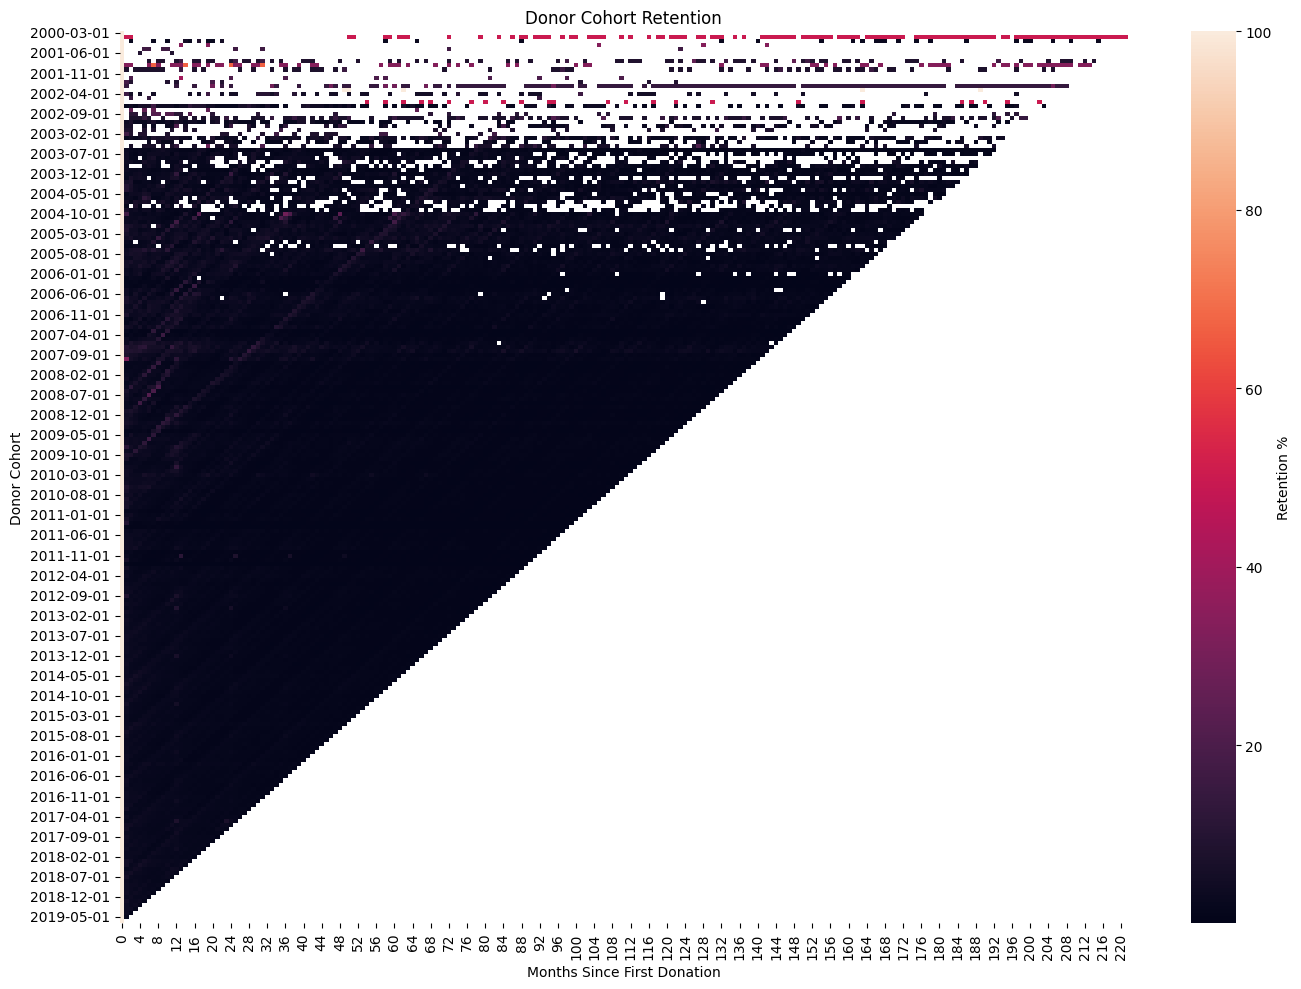

In [ ]:


cohort_pivot = cohort_df.pivot(
    index="cohort_month",
    columns="months_since_cohort",
    values="retention_percentage"
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cohort_pivot,
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Retention %"}
)

plt.title("Donor Cohort Retention")
plt.xlabel("Months Since First Donation")
plt.ylabel("Donor Cohort")

plt.tight_layout()
plt.show()

In [9]:
query = """
SELECT
    cohort_month,
    months_since_cohort,
    retention_percentage
FROM donor_cohort_retention
ORDER BY cohort_month, months_since_cohort;
"""

cohort_df = pd.read_sql_query(query, conn)

cohort_pivot = cohort_df.pivot(
    index="cohort_month",
    columns="months_since_cohort",
    values="retention_percentage"
)

print(cohort_pivot.shape)

(222, 222)


C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_14740\1334401969.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohort_df = pd.read_sql_query(query, conn)


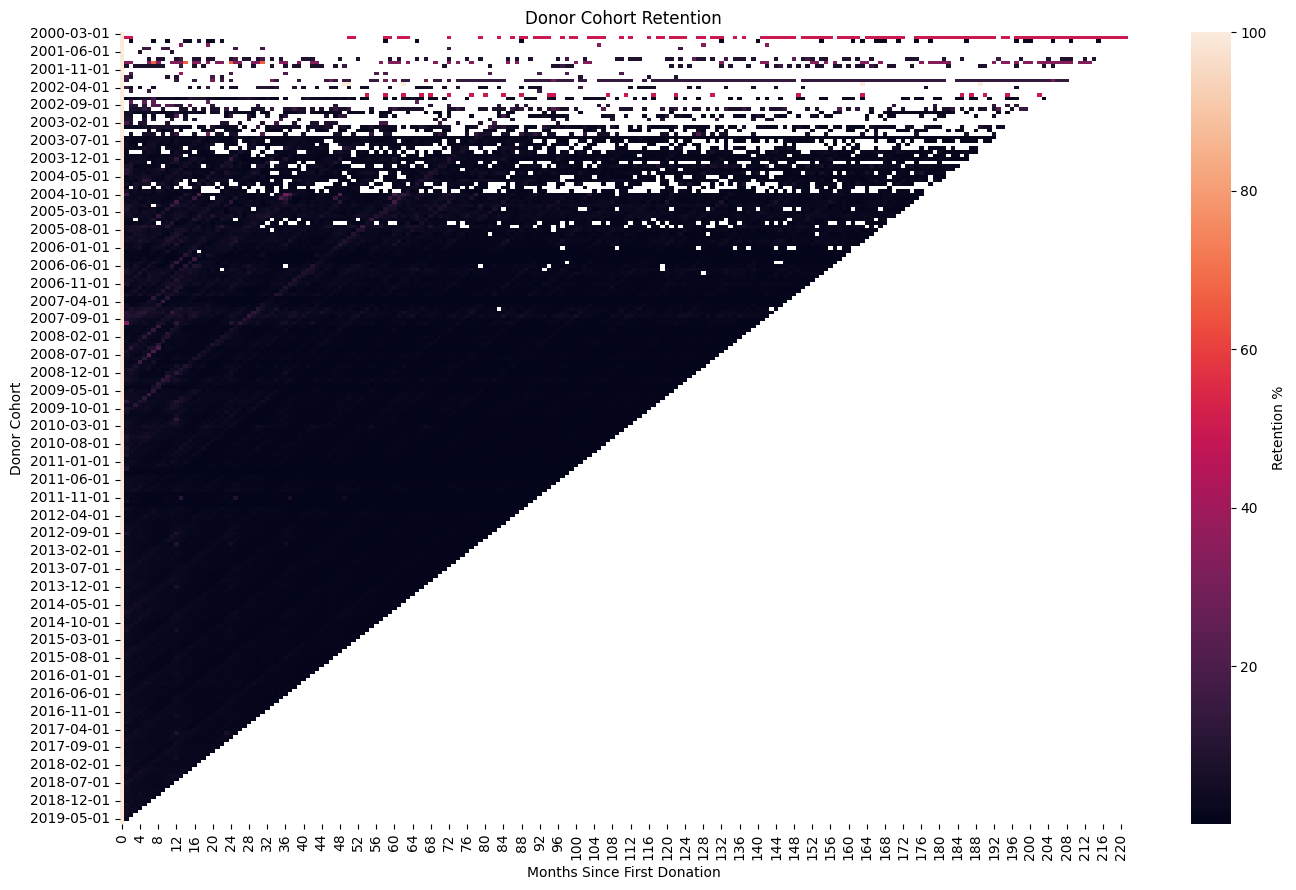

In [ ]:

plt.figure(figsize=(14, 9))

sns.heatmap(
    cohort_pivot,
    annot=False,
    cbar_kws={"label": "Retention %"}
)

plt.title("Donor Cohort Retention")
plt.xlabel("Months Since First Donation")
plt.ylabel("Donor Cohort")
plt.tight_layout()

plt.savefig(
    "../dashboard/cohort_retention_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cohort_df.to_csv(
    "../data/processed/cohort_retention.csv",
    index=False
)

print("Cohort retention table exported successfully!")

Cohort retention table exported successfully!


In [ ]:
query = """
SELECT
    created_month,
    COUNT(*) AS donations,
    ROUND(SUM(amount), 2) AS total_donated
FROM donations_raw
GROUP BY created_month
ORDER BY created_month;
"""

monthly_df = pd.read_sql_query(query, conn)

monthly_df.head()

C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_29448\259447847.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_df = pd.read_sql_query(query, conn)


,created_month,donations,total_donated
0,2000-03,1,100.00
1,2001-01,5,1799.39
2,2001-02,5,1781.27
3,2001-03,37,4292.00
4,2001-04,3,623.72


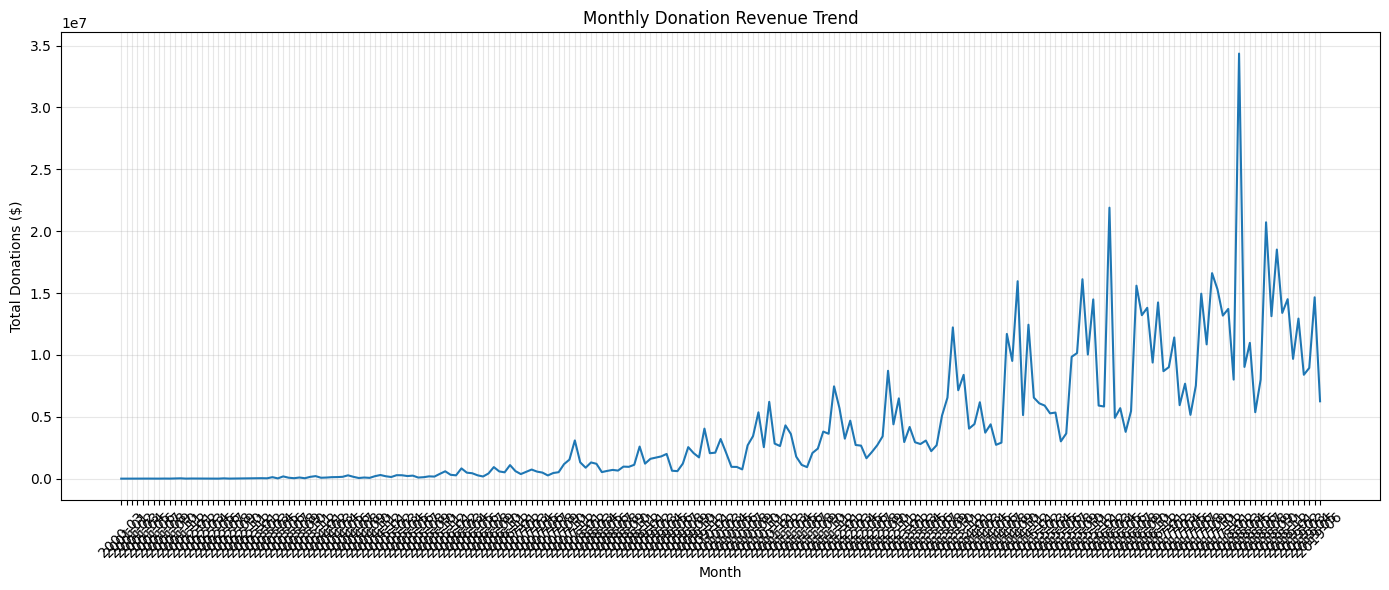

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_df["created_month"],
    monthly_df["total_donated"]
)

plt.title("Monthly Donation Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Donations ($)")
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
monthly_df.to_csv(
    "../data/processed/monthly_donation_trend.csv",
    index=False
)

print("Monthly trend table exported successfully!")

Monthly trend table exported successfully!


## 5. Statistical Testing

A Mann–Whitney U test was used to compare donor-level total donation values between one-time and repeat donors.

The test was selected because donation values are highly uneven across donors and may not follow a normal distribution.

The result was statistically significant (**p < 0.001**), providing strong evidence that the donation-value distributions of one-time and repeat donors differ.

Statistical significance does not by itself establish causation; the result is interpreted alongside the observed differences in donor frequency and monetary value.


## 6. Business Recommendations

The analysis suggests several practical retention priorities:

1. **Focus on the second donation:** With 71.08% of donors contributing only once, converting first-time donors into repeat donors is the largest retention opportunity.

2. **Prioritize At Risk donors:** The At Risk segment represents 20.43% of donors, making re-engagement an important opportunity for protecting future donation value.

3. **Protect high-value repeat donors:** Repeat donors contribute approximately 86.8% of total donation value, so maintaining engagement among loyal and high-value donors should be a priority.

4. **Use lifecycle-based engagement:** RFM and cohort analysis can be used to tailor retention strategies according to donor engagement, recency, frequency, and value.


## 7. Conclusion

DonorPulse demonstrates how large-scale transactional data can be transformed into actionable donor-retention insights using SQL, Python, statistical analysis, RFM segmentation, and cohort analysis.

The central finding is that while most donors contribute only once, repeat donors account for the majority of donation value. This makes retention and re-engagement critical levers for protecting long-term donation revenue.

The analysis provides a data-driven framework for identifying valuable, promising, and at-risk donor segments and prioritizing retention efforts accordingly.


In [ ]:
rfm_df.to_csv(
    "../data/processed/donor_rfm.csv",
    index=False
)

print("RFM table exported successfully!")

RFM table exported successfully!


C:\Users\Divyanshi diwan\AppData\Local\Temp\ipykernel_14740\2973420351.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  frequency_df = pd.read_sql_query(query, conn)


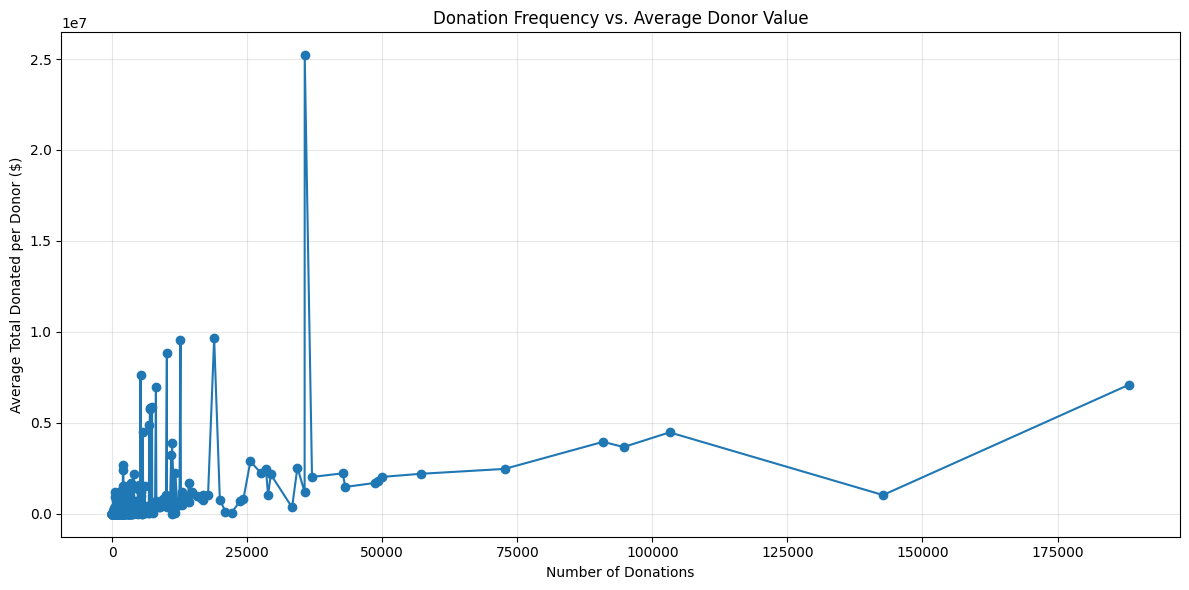

In [ ]:


query = """
SELECT
    donation_count,
    COUNT(*) AS donors,
    ROUND(AVG(total_donated), 2) AS avg_donated_per_donor
FROM (
    SELECT
        donor_id,
        COUNT(*) AS donation_count,
        SUM(amount) AS total_donated
    FROM donations_raw
    GROUP BY donor_id
) d
GROUP BY donation_count
ORDER BY donation_count;
"""

frequency_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 6))

plt.plot(
    frequency_df["donation_count"],
    frequency_df["avg_donated_per_donor"],
    marker="o"
)

plt.title("Donation Frequency vs. Average Donor Value")
plt.xlabel("Number of Donations")
plt.ylabel("Average Total Donated per Donor ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../dashboard/frequency_vs_donor_value.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:


print(os.path.exists("../dashboard/cohort_retention_heatmap.png"))
print(os.path.exists("../dashboard/frequency_vs_donor_value.png"))

True
True
